In [40]:
import os
import pickle
import numpy as np
import pandas as pd
from PIL import Image
import cv2
import networkx as nx
import shapely.geometry as geom
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from shapely.ops import unary_union
from gspan_mining.gspan import gSpan

In [33]:
# Mapping from RGB color to room type
COLOR_MAPPING = {
    (0xFF, 0xD7, 0x00): 'common_room',   # ffd700
    (0xFF, 0xA5, 0x00): 'master_room',   # ffa500
    (0xEE, 0xE8, 0xAA): 'living_room',   # eee8aa
    (0x6B, 0x8E, 0x23): 'balcony',       # 6b8e23
    (0xAD, 0xD8, 0xE6): 'bathroom',      # add8e6
    (0xF0, 0x80, 0x80): 'kitchen',       # f08080
    (0xDD, 0xA0, 0xDD): 'storage',       # dda0dd
    (0xDA, 0x70, 0xD6): 'dining',        # da70d6
}

# Minimum connected component size (in pixels) to keep
MIN_AREA_PX = 50

ROOM_LABEL2ID = {rtype: idx for idx, rtype in enumerate(sorted(set(COLOR_MAPPING.values())))}


In [24]:
def segment_room_polygons(image_path):
    """
    Segment each colored room in a floor plan to Shapely polygons.
    Returns: list of dicts with keys 'type','polygon','area','centroid'.
    """
    img = Image.open(image_path).convert('RGB')
    arr = np.array(img)
    rooms = []

    for color_rgb, rtype in COLOR_MAPPING.items():
        # binary mask for exact color
        mask = cv2.inRange(arr, np.array(color_rgb), np.array(color_rgb))
        if mask.sum() == 0:
            continue
        # find connected components
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)
        for label in range(1, num_labels):  # skip background
            if stats[label, cv2.CC_STAT_AREA] < MIN_AREA_PX:
                continue
            # extract component mask and contours
            comp_mask = (labels == label).astype(np.uint8) * 255
            contours, _ = cv2.findContours(comp_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for cnt in contours:
                if cv2.contourArea(cnt) < MIN_AREA_PX:
                    continue
                # cnt[:, 0, :] is Nx2 array of (x,y)
                coords = cnt.reshape(-1, 2)
                poly = geom.Polygon(coords)
                # fix invalid polygons
                if not poly.is_valid:
                    poly = poly.buffer(0)
                if poly.area < 1.0:
                    continue
                rooms.append({
                    'type': rtype,
                    'polygon': poly,
                    'area': poly.area,
                    'centroid': poly.centroid.coords[0],
                })
    return rooms


# def build_room_graph(rooms, adjacency_thresh=0.0):
#     """
#     Build NetworkX graph: nodes as rooms, edges if polygons touch or are within threshold.
#     """
#     G = nx.Graph()
#     for idx, room in enumerate(rooms):
#         G.add_node(idx,
#                    room_type=room['type'],
#                    area=room['area'],
#                    centroid=room['centroid'],
#                    polygon=room['polygon'])

#     nodes = list(G.nodes(data=True))
#     for i, (_, di) in enumerate(nodes):
#         for j, (_, dj) in enumerate(nodes[i+1:], start=i+1):
#             pi, pj = di['polygon'], dj['polygon']
#             # adjacency if touching or within threshold distance
#             if pi.touches(pj) or pi.distance(pj) <= adjacency_thresh:
#                 G.add_edge(i, j)
#     return G

def build_room_graph(rooms, adjacency_buffer=6.0):
    """
    Build a NetworkX graph of room adjacencies by buffering polygons
    to bridge thin walls/gaps and then testing for intersection.

    Args:
      rooms: list of dicts from segment_room_polygons
      adjacency_buffer: distance (px) to buffer each polygon
    """
    G = nx.Graph()
    for idx, room in enumerate(rooms):
        G.add_node(idx,
                   room_type=room['type'],
                   area=room['area'],
                   centroid=room['centroid'],
                   polygon=room['polygon'])

    # precompute buffered shapes
    buffered = {idx: data['polygon'].buffer(adjacency_buffer) for idx, data in G.nodes(data=True)}

    # test intersections between buffered & original
    nodes = list(G.nodes())
    for i in nodes:
        for j in nodes:
            if j <= i:
                continue
            if buffered[i].intersects(G.nodes[j]['polygon']):
                G.add_edge(i, j)
    return G


def overlay_polygons(image_path, rooms, figsize=(8,8), alpha=0.4):
    """
    Display the original image with colored polygon overlays.
    """
    img = np.array(Image.open(image_path).convert('RGB'))
    plt.figure(figsize=figsize)
    plt.imshow(img)
    ax = plt.gca()
    for room in rooms:
        poly = room['polygon']
        # get exterior coords
        x, y = poly.exterior.xy
        patch = MplPolygon(list(zip(x, y)), closed=True,
                           facecolor='none', edgecolor='red', linewidth=2, alpha=alpha)
        ax.add_patch(patch)
        # label at centroid
        cx, cy = room['centroid']
        ax.text(cx, cy, room['type'], fontsize=8, ha='center')
    plt.axis('off')
    plt.show()

def overlay_graph(image_path, rooms, graph, figsize=(8,8)):
    """
    Display the floor plan with room polygons and the adjacency graph overlaid.

    - Polygons: red outlines
    - Graph edges: blue lines between centroids
    - Graph nodes: white dots at centroids
    """
    img = np.array(Image.open(image_path).convert('RGB'))
    plt.figure(figsize=figsize)
    plt.imshow(img)
    ax = plt.gca()

    # draw polygons
    for room in rooms:
        poly = room['polygon']
        x, y = poly.exterior.xy
        patch = MplPolygon(list(zip(x, y)), closed=True,
                           facecolor='none', edgecolor='red', linewidth=1.5)
        ax.add_patch(patch)

    # draw edges and nodes
    for u, v in graph.edges():
        x1, y1 = graph.nodes[u]['centroid']
        x2, y2 = graph.nodes[v]['centroid']
        ax.plot([x1, x2], [y1, y2], linewidth=1.5, linestyle='-', color='blue')
    xs = [graph.nodes[n]['centroid'][0] for n in graph.nodes()]
    ys = [graph.nodes[n]['centroid'][1] for n in graph.nodes()]
    ax.scatter(xs, ys, s=30, facecolors='white', edgecolors='black', zorder=3)

    plt.axis('off')
    plt.show()


def process_images(image_dir):
    """
    Process all floorplan images in a directory.
    Returns list of dicts: {'filename','rooms','graph'}.
    """
    results = []
    for fname in os.listdir(image_dir):
        if not fname.lower().endswith(('.png','.jpg','.jpeg')):
            continue
        path = os.path.join(image_dir, fname)
        rooms = segment_room_polygons(path)
        G = build_room_graph(rooms)
        results.append({'filename': fname, 'rooms': rooms, 'graph': G})
    return results


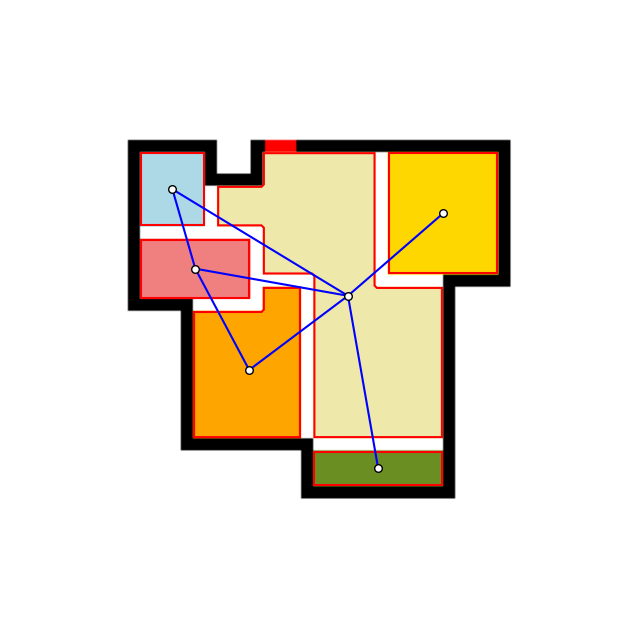

In [23]:
index = 2612
image_path = "./data/Tell2Design Data/General Data/floorplan_image/{}.png".format(index)

rooms = segment_room_polygons(image_path)
G = build_room_graph(rooms)
overlay_graph(image_path, rooms, G)

In [25]:
image_dir = "./data/Tell2Design Data/General Data/floorplan_image"

# Step 1.1: build graphs
graphs = process_images(image_dir)
print(f'Processed {len(graphs)} images into graphs')

Processed 80788 images into graphs


In [27]:
import pickle

with open('graphs.pkl', 'wb') as f:
    # 3. Dump (serialize) the object into the file
    pickle.dump(graphs, f)

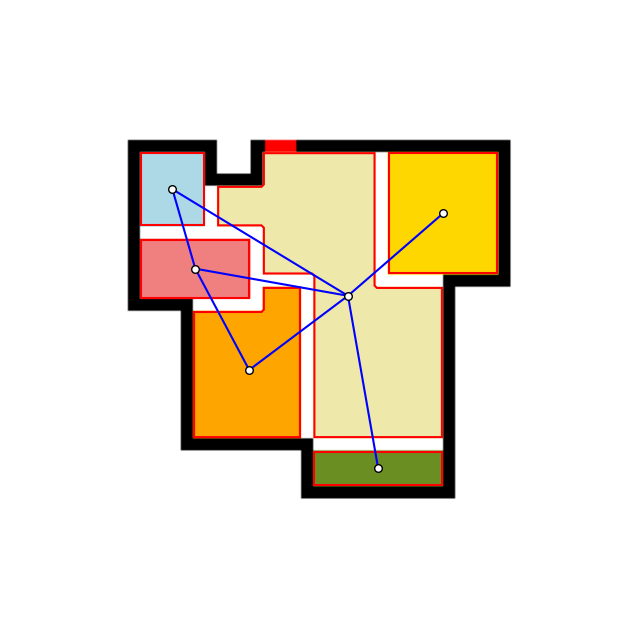

In [26]:
index = 2612
image_path = "./data/Tell2Design Data/General Data/floorplan_image/{}.png".format(index)

rooms = segment_room_polygons(image_path)
# G = build_room_graph(rooms)
overlay_graph(image_path, rooms, graphs[0]['graph'])

In [31]:
graphs

[{'filename': '2612.png',
  'rooms': [{'type': 'common_room',
    'polygon': <POLYGON ((157 59, 157 109, 202 109, 202 59, 157 59))>,
    'area': 2250.0,
    'centroid': (179.5, 84.0)},
   {'type': 'master_room',
    'polygon': <POLYGON ((105 115, 105 124, 104 125, 76 125, 76 177, 120 177, 120 115, 105 ...>,
    'area': 2438.5,
    'centroid': (98.8933087280432, 149.0876905201285)},
   {'type': 'living_room',
    'polygon': <POLYGON ((105 59, 105 72, 104 73, 86 73, 86 89, 104 89, 105 90, 105 109, 12...>,
    'area': 6042.0,
    'centroid': (139.9478925300673, 118.26762661370407)},
   {'type': 'balcony',
    'polygon': <POLYGON ((126 183, 126 197, 179 197, 179 183, 126 183))>,
    'area': 742.0,
    'centroid': (152.5, 190.0)},
   {'type': 'bathroom',
    'polygon': <POLYGON ((54 59, 54 89, 80 89, 80 59, 54 59))>,
    'area': 780.0,
    'centroid': (67.0, 74.0)},
   {'type': 'kitchen',
    'polygon': <POLYGON ((54 95, 54 119, 99 119, 99 95, 54 95))>,
    'area': 1080.0,
    'centroid': (

In [35]:

def write_gspan_input(graphs, out_file):
    """
    Dump a list of NetworkX graphs to a gSpan-format file.
    Uses integer labels for room types via ROOM_LABEL2ID.
    """
    with open(out_file, 'w') as f:
        for gid, G in enumerate(graphs, start=1):
            f.write(f't # {gid}\n')
            # vertices
            for nid, data in G.nodes(data=True):
                lbl = ROOM_LABEL2ID[data['room_type']]
                f.write(f'v {nid} {lbl}\n')
            # edges (unlabeled)
            for u, v in G.edges():
                f.write(f'e {u} {v} 0\n')
    return out_file

def mine_frequent_subgraphs(graphs, minsup=0.1, out_gspan='graphs.gspan', gspan_module=None):
    """
    Mine frequent subgraphs using gSpan. Returns a list of NX graphs.

    Parameters:
      graphs: list of NetworkX graphs
      minsup: float in (0,1], relative support threshold
      out_gspan: filename to write intermediate input
      gspan_module: optional imported gSpan class or function
    """
    inp = write_gspan_input(graphs, out_gspan)
    if gspan_module is None:
        from gspan_mining import gSpan as _gspan
    else:
        _gspan = gspan_module

    # Try both keyword and positional constructors for gSpan
    try:
        gs = _gspan(database=inp, support=minsup, is_undirected=True)
    except TypeError:
        gs = _gspan(inp, minsup, True)
    gs.run()
    # find attribute holding subgraphs
    for attr in ('_frequent_subgraphs','frequent_subgraphs','patterns','subgraphs'):
        if hasattr(gs, attr):
            items = getattr(gs, attr)
            break
    else:
        raise RuntimeError('No frequent subgraphs found in gSpan output')

    extracted = []
    for sub in items:
        # support both direct NX.Graph or wrapper
        g = getattr(sub, 'graph', sub)
        if not isinstance(g, nx.Graph):
            g = getattr(sub, '_graph', None) or sub[0]
        extracted.append(g)
    return extracted



def encode_subgraph(G, normalize=True, align=True):
    """
    Encode a subgraph by its node features: relative positions, degrees, type.

    Returns a canonical feature array sorted by node-label hash.
    """
    # extract centroids and types
    centroids = np.array([d['centroid'] for _, d in G.nodes(data=True)])
    types = [ROOM_LABEL2ID[d['room_type']] for _, d in G.nodes(data=True)]
    # center
    ctr = centroids.mean(axis=0)
    coords = centroids - ctr
    # align via PCA
    if align and len(coords) > 1:
        pca = PCA(n_components=2)
        coords = pca.fit_transform(coords)
    # normalize scale
    if normalize:
        maxd = np.linalg.norm(coords, axis=1).max() or 1.0
        coords = coords / maxd
    # collect features
    feats = []
    for nid, (coord, t) in enumerate(zip(coords, types)):
        deg = G.degree[nid]
        feats.append((t, round(coord[0],3), round(coord[1],3), deg))
    # sort for canonical order
    feats_sorted = sorted(feats)
    return feats_sorted


In [36]:
def visualize_graph(G, show_labels=True, figsize=(8,8)):
    """
    Draw the room adjacency graph. Nodes at centroids, edges between touching rooms.
    """
    pos = {n: d['centroid'] for n, d in G.nodes(data=True)}
    plt.figure(figsize=figsize)
    nx.draw(G, pos, with_labels=show_labels, node_size=300, edge_color='gray', node_color='skyblue')
    plt.axis('equal')
    plt.show()

def visualize_graph_overlay(image_path, G, show_labels=True, figsize=(8,8), alpha=0.7):
    """
    Overlay the adjacency graph on the original floor-plan image.
    """
    img = Image.open(image_path).convert('RGB')
    arr = np.array(img)
    pos = {n: d['centroid'] for n, d in G.nodes(data=True)}
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(arr)
    # draw edges
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='yellow', alpha=alpha)
    # draw nodes
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=100, node_color='red', alpha=alpha)
    if show_labels:
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color='white')
    ax.axis('off')
    plt.show()

In [23]:
image_dir = "./data/Tell2Design Data/General Data/floorplan_image"

# Step 1.1: build graphs
graphs = process_images(image_dir)
print(f'Processed {len(graphs)} images into graphs')


KeyboardInterrupt: 

In [38]:
index = 0
image_path = "./data/Tell2Design Data/General Data/floorplan_image/{}.png".format(index)

segment_room_polygons(image_path)
# visualize_graph_overlay(image_path, graphs[index], show_labels=True, figsize=(8,8), alpha=0.7)

[{'type': 'common_room',
  'polygon': <POLYGON ((72 87, 72 126, 124 126, 124 87, 72 87))>,
  'area': 2028.0,
  'centroid': (98.0, 106.5)},
 {'type': 'master_room',
  'polygon': <POLYGON ((72 161, 72 220, 124 220, 124 161, 72 161))>,
  'area': 3068.0,
  'centroid': (98.0, 190.5)},
 {'type': 'living_room',
  'polygon': <POLYGON ((148 28, 148 86, 147 87, 128 87, 128 129, 127 130, 111 130, 111 15...>,
  'area': 7901.0,
  'centroid': (153.8759861620892, 134.45091338649118)},
 {'type': 'balcony',
  'polygon': <POLYGON ((128 207, 128 228, 184 228, 184 207, 128 207))>,
  'area': 1176.0,
  'centroid': (156.0, 217.5)},
 {'type': 'bathroom',
  'polygon': <POLYGON ((72 130, 72 157, 107 157, 107 130, 72 130))>,
  'area': 945.0,
  'centroid': (89.5, 143.5)},
 {'type': 'kitchen',
  'polygon': <POLYGON ((115 53, 115 83, 144 83, 144 53, 115 53))>,
  'area': 870.0,
  'centroid': (129.5, 68.0)}]

In [9]:
graphs = pickle.load(open("graphs.pkl", "rb"))

In [41]:
out_gspan='floorplans.gspan'
# 1. Extract NetworkX graphs
nx_graphs = [item['graph'] for item in graphs]

# 2. Mine frequent subgraphs
print(f"Mining frequent subgraphs at minsup={minsup}, writing to '{out_gspan}'...")
patterns = mine_frequent_subgraphs(nx_graphs, minsup, out_gspan)
print(f"Found {len(patterns)} patterns.")

# 3. Encode each subgraph pattern
encodings = []
for i, G in enumerate(patterns, start=1):
    encoding = encode_subgraph(G)
    print(f"Pattern {i} encoding: {encoding}")
    encodings.append(encoding)


Mining frequent subgraphs at minsup=0.1, writing to 'floorplans.gspan'...
t # 0
v 0 2

Support: 79191

-----------------

t # 1
v 0 6

Support: 79536

-----------------

t # 2
v 0 5

Support: 80788

-----------------

t # 3
v 0 0

Support: 67620

-----------------

t # 4
v 0 1

Support: 80707

-----------------

t # 5
v 0 4

Support: 77626

-----------------

t # 6
v 0 3

Support: 1310

-----------------

t # 7
v 0 7

Support: 3253

-----------------

t # 8
v 0 2
v 1 5
e 0 1 0

Support: 78938


AttributeError: 'DataFrame' object has no attribute 'append'

In [27]:
encodings

[]